In [32]:
from utils.utils import set_seed
import numpy as np
import torch
set_seed(10)

from torch_geometric.datasets import TUDataset
dataset = TUDataset(root="/tmp/PTC_MR/", name="PTC_MR")

print(dataset)
print(f"number of graphs: {len(dataset)}")
print(f"number of classes: {dataset.num_classes}")
print(f"number of node features: {dataset.num_node_features}")
print(f"number of edge features: {dataset.num_edge_features}")

Seed fixada em 10
PTC_MR(344)
number of graphs: 344
number of classes: 2
number of node features: 18
number of edge features: 4


In [33]:
from utils.utils import create_data_splits

fold_loaders = create_data_splits(dataset, n_splits=4, batch_size=32)


Fold 1:
  Treino: 206 grafos
  Validação: 52 grafos
  Teste: 86 grafos


In [34]:
from models.HodgeGNN.hodge_gnn import  HodgeGNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando device: {device}')

# Criar modelo
model = HodgeGNN(
    num_edge_features= 4,
    use_edge_attr=True,
    num_classes=dataset.num_classes,
    hidden_dims=[32,32,32],
    mlp_hidden_dims= [64],  # 3 camadas
    pooling='max',  
    dropout=0.1,
    batch_norm=True,
    activation='leaky_relu',
    normalize_L1=True
)

Usando device: cpu


In [35]:
class GraphClassificationTrainer:
    def __init__(self, model, fold_loaders, config, device='cpu'):
        self.model = model.to(device)
        self.fold_loaders = fold_loaders
        self.config = config
        self.device = device
        
        # Configurando otimizador
        if config['optimizer'] == 'adam':
            self.optimizer = torch.optim.Adam(
                model.parameters(),
                lr=config['lr'],
                weight_decay=config['weight_decay']
            )
        
        # Scheduler de learning rate
        if config.get('scheduler') == 'step':
            self.scheduler = torch.optim.lr_scheduler.StepLR(
                self.optimizer,
                step_size=config['step_size'],
                gamma=config['gamma']
            )
        elif config.get('scheduler') == 'cosine':
            self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer,
                T_max=config['epochs']
            )
        else:
            self.scheduler = None
        
        self.criterion = torch.nn.CrossEntropyLoss()
        
        # Para early stopping
        self.best_val_acc = 0
        self.patience_counter = 0
        self.best_model_state = None
    
    def train_epoch(self, train_loader):
        """
        Treina por uma época completa, iterando sobre todos os batches.
        """
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for batch in train_loader:
            batch = batch.to(self.device)
            
            self.optimizer.zero_grad()
            
            # Forward pass - ADICIONAR edge_attr! ✅
            out = self.model(batch.x, batch.edge_index, batch.batch,
                           edge_attr=batch.edge_attr if hasattr(batch, 'edge_attr') else None)
            
            loss = self.criterion(out, batch.y)
            loss.backward()
            
            if self.config.get('clip_grad'):
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(),
                    self.config['clip_grad']
                )
            
            self.optimizer.step()
            
            total_loss += loss.item() * batch.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
            total += batch.num_graphs
        
        avg_loss = total_loss / total
        accuracy = correct / total
        
        return avg_loss, accuracy
    
    @torch.no_grad()
    def evaluate(self, loader):
        """
        Avalia o modelo em um DataLoader específico.
        """
        self.model.eval()
        correct = 0
        total = 0
        
        for batch in loader:
            batch = batch.to(self.device)
            
            # ADICIONAR edge_attr! ✅
            out = self.model(batch.x, batch.edge_index, batch.batch,
                           edge_attr=batch.edge_attr if hasattr(batch, 'edge_attr') else None)
            
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
            total += batch.num_graphs
        
        return correct / total
    
    def train_fold(self, fold_idx):
        """
        Treina o modelo em um fold específico da validação cruzada.
        """
        print(f'\n=== Treinando Fold {fold_idx + 1} ===')
        
        # Reseta o modelo para cada fold
        self.model.apply(self._weight_reset)
        
        # Reseta otimizador e scheduler
        self.__init__(self.model, self.fold_loaders, self.config, self.device)
        
        loaders = self.fold_loaders[fold_idx]
        train_loader = loaders['train']
        val_loader = loaders['val']
        test_loader = loaders['test']
        
        history = {
            'train_loss': [],
            'train_acc': [],
            'val_acc': [],
            'test_acc': []
        }
        
        self.best_val_acc = 0
        self.patience_counter = 0
        
        for epoch in range(1, self.config['epochs'] + 1):
            # Treina por uma época
            train_loss, train_acc = self.train_epoch(train_loader)
            
            # Avalia em validação e teste
            val_acc = self.evaluate(val_loader)
            test_acc = self.evaluate(test_loader)
            
            # Guarda histórico
            history['train_loss'].append(train_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
            history['test_acc'].append(test_acc)
            
            # Atualiza learning rate
            if self.scheduler is not None:
                self.scheduler.step()
            
            # Early stopping
            if self.config.get('early_stopping'):
                if val_acc > self.best_val_acc:
                    self.best_val_acc = val_acc
                    self.best_model_state = self.model.state_dict().copy()
                    self.patience_counter = 0
                else:
                    self.patience_counter += 1
                
                if self.patience_counter >= self.config['patience']:
                    print(f'Early stopping na época {epoch}')
                    self.model.load_state_dict(self.best_model_state)
                    break
            
            # Log periódico
            if epoch % self.config['log_interval'] == 0:
                print(f'Época {epoch:03d}: Loss={train_loss:.4f}, '
                      f'Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')
        
        # Avaliação final no melhor modelo
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
        
        final_val_acc = self.evaluate(val_loader)
        final_test_acc = self.evaluate(test_loader)
        
        print(f'Melhor Val Acc: {final_val_acc:.4f}')
        print(f'Test Acc final: {final_test_acc:.4f}')
        
        return history, final_val_acc, final_test_acc
    
    def train_all_folds(self):
        """
        Executa validação cruzada completa em todos os folds.
        """
        val_accs = []
        test_accs = []
        all_histories = []
        
        for fold_idx in range(len(self.fold_loaders)):
            history, val_acc, test_acc = self.train_fold(fold_idx)
            val_accs.append(val_acc)
            test_accs.append(test_acc)
            all_histories.append(history)
        
        # Calcula estatísticas agregadas
        mean_val_acc = np.mean(val_accs)
        std_val_acc = np.std(val_accs)
        mean_test_acc = np.mean(test_accs)
        std_test_acc = np.std(test_accs)
        
        print('\n' + '='*50)
        print('RESULTADOS DA VALIDAÇÃO CRUZADA')
        print('='*50)
        print(f'Validação: {mean_val_acc:.4f} ± {std_val_acc:.4f}')
        print(f'Teste: {mean_test_acc:.4f} ± {std_test_acc:.4f}')
        print('='*50)
        
        return {
            'val_accs': val_accs,
            'test_accs': test_accs,
            'mean_val_acc': mean_val_acc,
            'std_val_acc': std_val_acc,
            'mean_test_acc': mean_test_acc,
            'std_test_acc': std_test_acc,
            'histories': all_histories
        }
    
    @staticmethod
    def _weight_reset(m):
        """
        Reseta os pesos de uma camada para reinicialização.
        """
        if hasattr(m, 'reset_parameters'):
            m.reset_parameters()

In [36]:
# Configuração de treinamento
config = {
    'optimizer': 'adam',
    'lr': 0.0005,
    'weight_decay': 0.001,
    # 'scheduler': 'step',
    # 'step_size': 50,
    # 'gamma': 0.5,
    'epochs': 50,
    # 'clip_grad': 1.0,
    # 'early_stopping': True,
    # 'patience': 50,
    'log_interval': 10
}

# Treinar com seu trainer existente!
trainer = GraphClassificationTrainer(model, fold_loaders, config, device=device)
results = trainer.train_all_folds()

print("\n Resultados HodgeGNN:")
print(f"Validação: {results['mean_val_acc']:.4f} ± {results['std_val_acc']:.4f}")
print(f"Teste: {results['mean_test_acc']:.4f} ± {results['std_test_acc']:.4f}")


=== Treinando Fold 1 ===
Época 010: Loss=0.6801, Train=0.5534, Val=0.5577, Test=0.5581
Época 020: Loss=0.6837, Train=0.5680, Val=0.5577, Test=0.5581
Época 030: Loss=0.6932, Train=0.5485, Val=0.5577, Test=0.5581
Época 040: Loss=0.6836, Train=0.5680, Val=0.5577, Test=0.5581
Época 050: Loss=0.6879, Train=0.5631, Val=0.5577, Test=0.5581
Melhor Val Acc: 0.5577
Test Acc final: 0.5581

=== Treinando Fold 2 ===
Época 010: Loss=0.6818, Train=0.5777, Val=0.4423, Test=0.4419
Época 020: Loss=0.6851, Train=0.5340, Val=0.4423, Test=0.4419
Época 030: Loss=0.6974, Train=0.4903, Val=0.4423, Test=0.4419
Época 040: Loss=0.6901, Train=0.5631, Val=0.4423, Test=0.4419
Época 050: Loss=0.6882, Train=0.5728, Val=0.4423, Test=0.4419
Melhor Val Acc: 0.4423
Test Acc final: 0.4419

=== Treinando Fold 3 ===
Época 010: Loss=0.6956, Train=0.5146, Val=0.4423, Test=0.4419
Época 020: Loss=0.6877, Train=0.5194, Val=0.4423, Test=0.4419
Época 030: Loss=0.6914, Train=0.5000, Val=0.4423, Test=0.4419
Época 040: Loss=0.6975, 

Coletando predições de todos os folds no conjunto de teste...
Fold 1: 86 amostras coletadas
Fold 2: 86 amostras coletadas
Fold 3: 86 amostras coletadas
Fold 4: 86 amostras coletadas

Total de amostras: 344


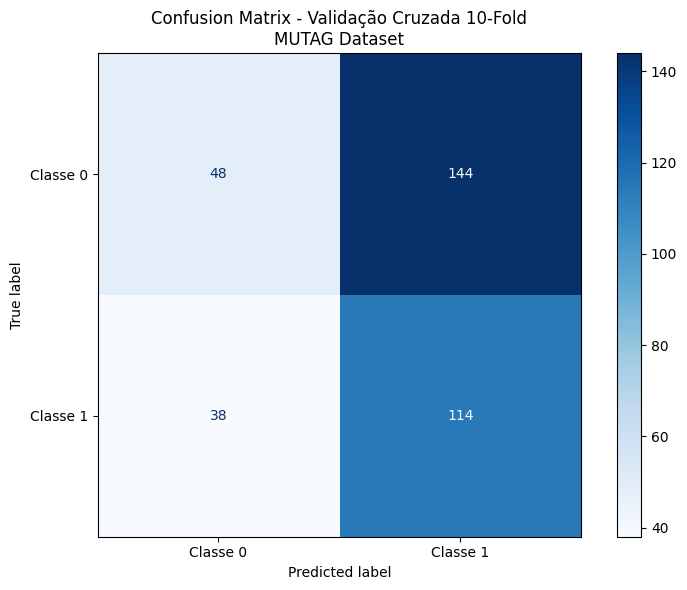


MATRIZ DE CONFUSÃO
True Negatives (TN): 48
False Positives (FP): 144
False Negatives (FN): 38
True Positives (TP): 114

Métricas:
Accuracy: 0.4709
Precision: 0.4419
Recall: 0.7500
F1-Score: 0.5561


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_predictions_for_fold(model, loader, device):
    """
    Coleta todas as predições e labels verdadeiros para um loader.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch,
                        edge_attr = batch.edge_attr if hasattr(batch, "edge_attr") else None)
            pred = out.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
    
    return all_preds, all_labels

# Treinar novamente o último fold para ter o modelo carregado
# Ou podemos coletar predições de todos os folds
all_preds = []
all_labels = []

print("Coletando predições de todos os folds no conjunto de teste...")

for fold_idx in range(len(fold_loaders)):
    # Reseta e treina o modelo para este fold
    trainer.model.apply(trainer._weight_reset)
    trainer.__init__(trainer.model, fold_loaders, config, device=device)
    
    # Treina o fold silenciosamente
    loaders = fold_loaders[fold_idx]
    train_loader = loaders['train']
    val_loader = loaders['val']
    test_loader = loaders['test']
    
    best_val_acc = 0
    patience_counter = 0
    best_model_state = None
    
    # Treinamento simplificado sem prints
    for epoch in range(1, config['epochs'] + 1):
        trainer.model.train()
        for batch in train_loader:
            batch = batch.to(device)
            trainer.optimizer.zero_grad()
            out = trainer.model( batch.x, batch.edge_index, batch.batch, 
                                edge_attr = batch.edge_attr if hasattr(batch, "edge_attr") else None) 
            loss = trainer.criterion(out, batch.y)
            loss.backward()
            if config.get('clip_grad'):
                torch.nn.utils.clip_grad_norm_(trainer.model.parameters(), config['clip_grad'])
            trainer.optimizer.step()
        
        if trainer.scheduler is not None:
            trainer.scheduler.step()
        
        # Validação para early stopping
        val_acc = trainer.evaluate(val_loader)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = trainer.model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        # if patience_counter >= config['patience']:
        #     break
    
    # Carrega o melhor modelo
    if best_model_state is not None:
        trainer.model.load_state_dict(best_model_state)
    
    # Coleta predições do conjunto de teste
    preds, labels = get_predictions_for_fold(trainer.model, test_loader, device)
    all_preds.extend(preds)
    all_labels.extend(labels)
    
    print(f"Fold {fold_idx + 1}: {len(preds)} amostras coletadas")

print(f"\nTotal de amostras: {len(all_preds)}")

# Criar a matriz de confusão
cm = confusion_matrix(all_labels, all_preds)

# Plotar a matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Validação Cruzada 10-Fold\nMUTAG Dataset')
plt.tight_layout()
plt.show()

# Imprimir estatísticas
print("\n" + "="*50)
print("MATRIZ DE CONFUSÃO")
print("="*50)
print(f"True Negatives (TN): {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives (TP): {cm[1,1]}")
print("\nMétricas:")
accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
precision = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
recall = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("="*50)